# Load csv

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "aclImdb"

train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

train_df.head()

Training shape: (25000, 2)
Testing shape: (25000, 2)


,text,label
0,Bromwell High is a cartoon comedy. It ran at t...,1
1,Homelessness (or Houselessness as George Carli...,1
2,Brilliant over-acting by Lesley Ann Warren. Be...,1
3,This is easily the most underrated film inn th...,1
4,This is not the typical Mel Brooks film. It wa...,1


# EDA

## info

In [2]:
print("Training Info")
train_df.info()

print("\nTesting Info")
test_df.info()

Training Info
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    25000 non-null  str  
 1   label   25000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 390.8 KB

Testing Info
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    25000 non-null  str  
 1   label   25000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 390.8 KB


## describe

In [3]:
train_df.describe(include="all")

,text,label
count,25000,25000.00000
unique,24904,NaN
top,You do realize that you've been watching the E...,NaN
freq,3,NaN
mean,NaN,0.50000
std,NaN,0.50001
min,NaN,0.00000
25%,NaN,0.00000
50%,NaN,0.50000
75%,NaN,1.00000


## value counts

In [4]:
print(train_df["label"].value_counts())

label
1    12500
0    12500
Name: count, dtype: int64


## duplicates

In [5]:
print("Training duplicates:", train_df.duplicated().sum())
print("Testing duplicates:", test_df.duplicated().sum())

Training duplicates: 96
Testing duplicates: 199


## Check whether any review is empty

In [6]:
print("Empty training reviews:",
      train_df["text"].str.strip().eq("").sum())

print("Empty testing reviews:",
      test_df["text"].str.strip().eq("").sum())

Empty training reviews: 0
Empty testing reviews: 0


## Review length distribution

In [7]:
train_df["review_length"] = train_df["text"].str.split().str.len()
train_df["review_length"].describe()

count    25000.000000
mean       233.787200
std        173.733032
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: review_length, dtype: float64

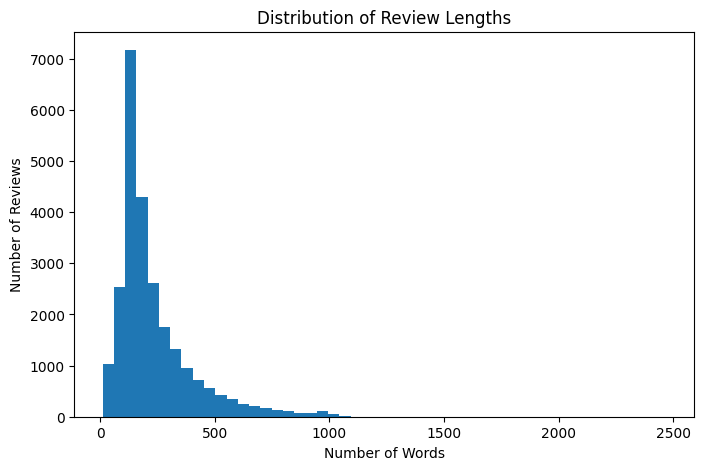

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(train_df["review_length"], bins=50)
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.show()

Review lengths right-skewed, with most reviews containing between 100 and 300 words.

 The  the average review lengrh is 234 words. The longest review contains 2,470 words, but such cases are rare. 
 
=> most reviews have a moderate length, which can help when choosing an appropriate maximum sequence length for the models

## Review length by sentiment

<Figure size 800x500 with 0 Axes>

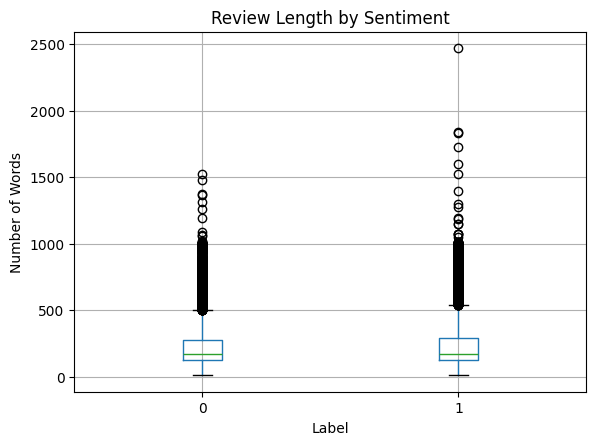

In [9]:
plt.figure(figsize=(8,5))
train_df.boxplot(column="review_length", by="label")
plt.title("Review Length by Sentiment")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("Number of Words")
plt.show()

The review lengths for both positive and negative reviews are very similar.

Both classes contain some very long outlier reviews => review length alone is unlikely to distinguish between positive and negative sentiments

## HTML tags

In [10]:
html_train = train_df["text"].str.contains(r"<.*?>", regex=True).sum()
html_test = test_df["text"].str.contains(r"<.*?>", regex=True).sum()

print(f"Training reviews containing HTML tags: {html_train}")
print(f"Testing reviews containing HTML tags: {html_test}")

Training reviews containing HTML tags: 14667
Testing reviews containing HTML tags: 14535


# Preprocessing

## Drop duplicates

In [11]:
train_df = train_df.drop_duplicates(ignore_index=True)
test_df = test_df.drop_duplicates(ignore_index=True)

In [12]:
print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

print("Training duplicates:", train_df.duplicated().sum())
print("Testing duplicates:", test_df.duplicated().sum())

Training shape: (24904, 3)
Testing shape: (24801, 2)
Training duplicates: 0
Testing duplicates: 0


## Expand contractions

In [13]:
contractions = {
"ain't": "am not",
"aren't": "are not",
"can't": "cannot",
"can't've": "cannot have",
"'cause": "because",
"could've": "could have",
"couldn't": "could not",
"couldn't've": "could not have",
"didn't": "did not",
"doesn't": "does not",
"don't": "do not",
"hadn't": "had not",
"hadn't've": "had not have",
"hasn't": "has not",
"haven't": "have not",
"he'd": "he would",
"he'd've": "he would have",
"he'll": "he will",
"he's": "he is",
"how'd": "how did",
"how'll": "how will",
"how's": "how is",
"i'd": "i would",
"i'll": "i will",
"i'm": "i am",
"i've": "i have",
"isn't": "is not",
"it'd": "it would",
"it'll": "it will",
"it's": "it is",
"let's": "let us",
"ma'am": "madam",
"mayn't": "may not",
"might've": "might have",
"mightn't": "might not",
"must've": "must have",
"mustn't": "must not",
"needn't": "need not",
"oughtn't": "ought not",
"shan't": "shall not",
"sha'n't": "shall not",
"she'd": "she would",
"she'll": "she will",
"she's": "she is",
"should've": "should have",
"shouldn't": "should not",
"that'd": "that would",
"that's": "that is",
"there'd": "there had",
"there's": "there is",
"they'd": "they would",
"they'll": "they will",
"they're": "they are",
"they've": "they have",
"wasn't": "was not",
"we'd": "we would",
"we'll": "we will",
"we're": "we are",
"we've": "we have",
"weren't": "were not",
"what'll": "what will",
"what're": "what are",
"what's": "what is",
"what've": "what have",
"where'd": "where did",
"where's": "where is",
"who'll": "who will",
"who's": "who is",
"won't": "will not",
"wouldn't": "would not",
"you'd": "you would",
"you'll": "you will",
"you're": "you are"
}

In [14]:
def decontract_words(text):
    words = text.split()
    expanded_words = []

    for word in words:
        expanded_words.append(contractions.get(word, word))

    return " ".join(expanded_words)

## HTML tags

In [15]:
import re

def format_text_regex(text):
   
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"&amp;", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

## Remove stopwords

In [16]:
import nltk
from nltk.corpus import stopwords

In [17]:
nltk.download("stopwords")

stops = set(stopwords.words("english"))
stops -= {"not", "no", "nor"}

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stops]
    return " ".join(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Apply all functions

In [18]:

def clean_text(text):

    # Convert words to lower case
    text = text.lower()

    # Use other preprocessing functions
    text = decontract_words(text)
    text = format_text_regex(text)
    text = remove_stopwords(text)

    # Tokenize each word
    text =  nltk.WordPunctTokenizer().tokenize(text)

    return text

In [19]:
train_df["tokens"] = train_df["text"].apply(clean_text)
test_df["tokens"] = test_df["text"].apply(clean_text)

In [20]:
print(train_df[["text", "tokens"]].head())

                                                text  \
0  Bromwell High is a cartoon comedy. It ran at t...   
1  Homelessness (or Houselessness as George Carli...   
2  Brilliant over-acting by Lesley Ann Warren. Be...   
3  This is easily the most underrated film inn th...   
4  This is not the typical Mel Brooks film. It wa...   

                                              tokens  
0  [bromwell, high, cartoon, comedy, ran, time, p...  
1  [homelessness, houselessness, george, carlin, ...  
2  [brilliant, acting, lesley, ann, warren, best,...  
3  [easily, underrated, film, inn, brooks, cannon...  
4  [not, typical, mel, brooks, film, much, less, ...  


## Lemmatization

In [21]:
from nltk.stem import WordNetLemmatizer
nltk.download("wordnet")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [22]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

In [23]:
train_df["tokens"]=train_df["tokens"].apply(lemmatize_tokens)
test_df["tokens"]=test_df["tokens"].apply(lemmatize_tokens)

In [24]:
# check
print(train_df.loc[0, "tokens"][:30])

['bromwell', 'high', 'cartoon', 'comedy', 'ran', 'time', 'program', 'school', 'life', 'teacher', '35', 'year', 'teaching', 'profession', 'lead', 'believe', 'bromwell', 'high', 'satire', 'much', 'closer', 'reality', 'teacher', 'scramble', 'survive', 'financially', 'insightful', 'student', 'see', 'right']


# Post Preprocessing analysis

## Most frequent words after preprocessing

In [25]:
from collections import Counter

all_words = [word for review in train_df["tokens"] for word in review]
word_counts = Counter(all_words)
word_counts.most_common(20)

[('not', 58981),
 ('movie', 51553),
 ('film', 46937),
 ('one', 27659),
 ('like', 20686),
 ('time', 15890),
 ('would', 15534),
 ('good', 15166),
 ('character', 14138),
 ('story', 13133),
 ('no', 12674),
 ('even', 12617),
 ('get', 12480),
 ('make', 12197),
 ('see', 11976),
 ('really', 11702),
 ('well', 10762),
 ('scene', 10578),
 ('much', 9730),
 ('people', 9351)]

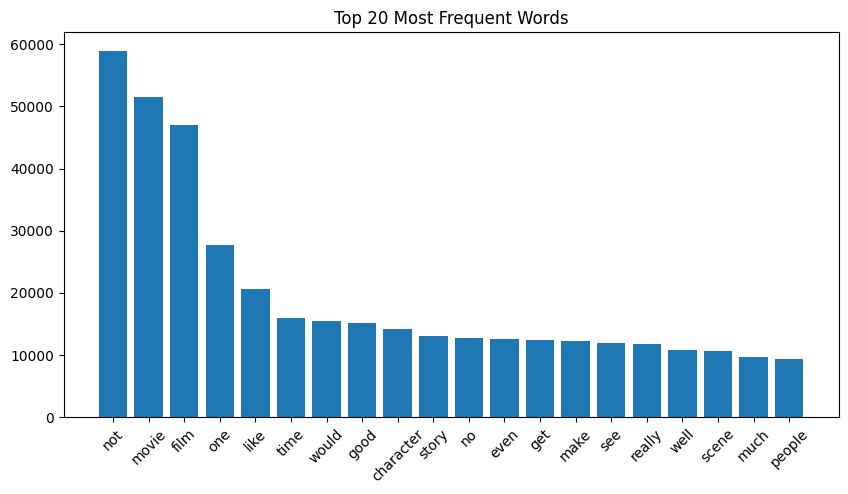

In [26]:
top_words = word_counts.most_common(20)

words = [w for w, _ in top_words]
counts = [c for _, c in top_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.show()

# Save the preprocessed data

In [27]:
train_df["processed_text"] = train_df["tokens"].apply(lambda tokens: " ".join(tokens))
test_df["processed_text"] = test_df["tokens"].apply(lambda tokens: " ".join(tokens))

In [28]:
train_processed = train_df[["processed_text", "label"]]
test_processed = test_df[["processed_text", "label"]]

In [29]:
train_processed.to_csv(DATA_DIR / "train_processed.csv", index=False)
test_processed.to_csv(DATA_DIR / "test_processed.csv", index=False)

print("Preprocessed datasets saved.")

Preprocessed datasets saved.
